# Interpretazione di una rete neurale per compliance normativa in ambito bancario

**Caso di studio:** Banca Virtuosa vuole rendere piu trasparenti i modelli di intelligenza artificiale usati nei propri sistemi.  
In questo notebook usiamo un esempio didattico con immagini, perche le mappe di salienza sono facili da visualizzare e interpretare.

L'idea e la stessa che si userebbe in ambito bancario: non basta sapere che il modello ha prodotto una decisione, bisogna anche capire **quali informazioni hanno influenzato quella decisione**.

Il notebook e pensato per essere eseguito in **Google Colab**.


## Obiettivi del progetto

1. Usare una rete neurale pre-addestrata, cioe **DenseNet121** da `torchvision`.
2. Applicarla a un dataset di immagini, in questo caso **CIFAR-10**.
3. Generare mappe di salienza con tre tecniche di Explainable AI:
   - **Grad-CAM**
   - **Integrated Gradients**
   - **Occlusion Map**
4. Confrontare una classificazione corretta e una classificazione errata.
5. Scrivere una breve interpretazione finale collegata a trasparenza, controllo degli errori e compliance normativa.

Nota: CIFAR-10 non e un dataset bancario. Viene usato come esempio semplice e pubblico. In un'applicazione reale bancaria, lo stesso ragionamento si applicherebbe a modelli su transazioni, richieste di credito, profili cliente o segnalazioni antifrode.


## 1. Import delle librerie

Questa cella carica le librerie principali e imposta un seme casuale per rendere i risultati piu riproducibili.


In [1]:
import os
import random
import warnings

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

import torchvision
from torchvision import datasets, transforms
from torchvision.models import densenet121

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo usato:", device)
print("Versione PyTorch:", torch.__version__)
print("Versione Torchvision:", torchvision.__version__)


Dispositivo usato: cpu
Versione PyTorch: 2.11.0+cpu
Versione Torchvision: 0.26.0+cpu


## 2. Dataset: CIFAR-10

CIFAR-10 contiene immagini a colori divise in 10 classi:

`airplane`, `automobile`, `bird`, `cat`, `deer`, `dog`, `frog`, `horse`, `ship`, `truck`.

Per rendere l'esecuzione piu rapida in Colab, useremo solo un sottoinsieme del dataset. Le immagini vengono ridimensionate e normalizzate nel formato atteso dalla rete pre-addestrata.


In [2]:
IMAGE_SIZE = 128
BATCH_SIZE = 32
TRAIN_SIZE = 2000
TEST_SIZE = 500

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

data_root = "/content/data" if os.path.exists("/content") else "./data"

train_full = datasets.CIFAR10(root=data_root, train=True, download=True, transform=train_transform)
test_full = datasets.CIFAR10(root=data_root, train=False, download=True, transform=test_transform)

class_names = train_full.classes
print("Classi:", class_names)

rng = torch.Generator().manual_seed(SEED)
train_indices = torch.randperm(len(train_full), generator=rng)[:TRAIN_SIZE]
test_indices = torch.randperm(len(test_full), generator=rng)[:TEST_SIZE]

train_dataset = Subset(train_full, train_indices)
test_dataset = Subset(test_full, test_indices)

num_workers = 2 if os.name != "nt" else 0
pin_memory = torch.cuda.is_available()

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=num_workers, pin_memory=pin_memory)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)

print("Immagini di training usate:", len(train_dataset))
print("Immagini di test usate:", len(test_dataset))


100%|██████████| 170M/170M [00:03<00:00, 48.6MB/s]


Classi: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Immagini di training usate: 2000
Immagini di test usate: 500


## 3. Visualizzazione di alcune immagini

Prima di usare il modello, osserviamo qualche immagine del dataset.


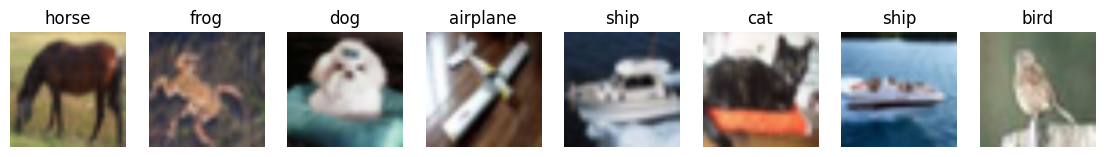

In [3]:
mean_tensor = torch.tensor(imagenet_mean).view(3, 1, 1)
std_tensor = torch.tensor(imagenet_std).view(3, 1, 1)


def denormalize(image_tensor):
    image = image_tensor.detach().cpu() * std_tensor + mean_tensor
    image = image.clamp(0, 1)
    return image


def show_batch(dataset, n=8):
    plt.figure(figsize=(14, 3))
    for i in range(n):
        image, label = dataset[i]
        image = denormalize(image).permute(1, 2, 0).numpy()
        plt.subplot(1, n, i + 1)
        plt.imshow(image)
        plt.title(class_names[label])
        plt.axis("off")
    plt.show()

show_batch(test_dataset, n=8)


## 4. Modello: DenseNet121 pre-addestrata

Useremo **DenseNet121**, una rete convoluzionale pre-addestrata su ImageNet.  
Per adattarla a CIFAR-10 sostituiamo l'ultimo classificatore con un classificatore da 10 classi.

Per mantenere il notebook veloce:

- blocchiamo i pesi della parte convoluzionale gia pre-addestrata;
- addestriamo solo l'ultimo strato di classificazione.


In [4]:
def build_densenet_for_cifar10(num_classes=10):
    try:
        from torchvision.models import DenseNet121_Weights
        weights = DenseNet121_Weights.DEFAULT
        model = densenet121(weights=weights)
        print("DenseNet121 caricata con pesi pre-addestrati aggiornati.")
    except Exception:
        model = densenet121(pretrained=True)
        print("DenseNet121 caricata con la sintassi pretrained=True.")

    for parameter in model.features.parameters():
        parameter.requires_grad = False

    input_features = model.classifier.in_features
    model.classifier = nn.Linear(input_features, num_classes)
    return model

model = build_densenet_for_cifar10(num_classes=len(class_names)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)

print(model.classifier)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 103MB/s]


DenseNet121 caricata con pesi pre-addestrati aggiornati.
Linear(in_features=1024, out_features=10, bias=True)


## 5. Addestramento rapido

Questa fase serve solo ad adattare il classificatore finale alle classi di CIFAR-10.  
L'obiettivo principale del progetto non e ottenere la massima accuratezza, ma produrre spiegazioni interpretabili delle decisioni del modello.


In [5]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    model.features.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_predictions = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        predictions = outputs.argmax(dim=1)

        total_loss += loss.item() * images.size(0)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy, np.array(all_labels), np.array(all_predictions)


EPOCHS = 2
history = []

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader, criterion)
    history.append((train_loss, train_acc, test_loss, test_acc))

    print(f"Epoca {epoch + 1}/{EPOCHS}")
    print(f"  Training - loss: {train_loss:.4f}, accuracy: {train_acc:.3f}")
    print(f"  Test     - loss: {test_loss:.4f}, accuracy: {test_acc:.3f}")


Epoca 1/2
  Training - loss: 1.1540, accuracy: 0.619
  Test     - loss: 0.6749, accuracy: 0.790
Epoca 2/2
  Training - loss: 0.4931, accuracy: 0.860
  Test     - loss: 0.5366, accuracy: 0.818


## 6. Valutazione del modello

Osserviamo l'accuratezza e una matrice di confusione.  
La matrice di confusione mostra dove il modello confonde una classe con un'altra.


Accuratezza finale sul test subset: 0.818


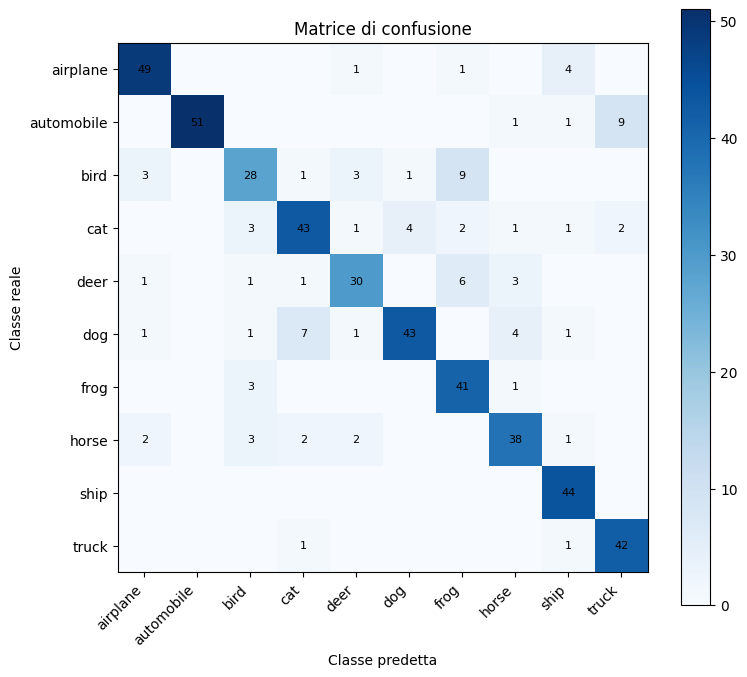

In [6]:
test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader, criterion)
print(f"Accuratezza finale sul test subset: {test_acc:.3f}")

confusion = np.zeros((len(class_names), len(class_names)), dtype=int)
for true_label, predicted_label in zip(y_true, y_pred):
    confusion[true_label, predicted_label] += 1

plt.figure(figsize=(8, 7))
plt.imshow(confusion, cmap="Blues")
plt.title("Matrice di confusione")
plt.xlabel("Classe predetta")
plt.ylabel("Classe reale")
plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(range(len(class_names)), class_names)
plt.colorbar()

for i in range(len(class_names)):
    for j in range(len(class_names)):
        value = confusion[i, j]
        if value > 0:
            plt.text(j, i, str(value), ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()


## 7. Scelta di un esempio corretto e di un esempio errato

Per interpretare il modello e utile confrontare:

- una decisione corretta;
- una decisione sbagliata.

Le tecniche XAI verranno calcolate sulla **classe predetta**, perche vogliamo capire perche il modello ha scelto proprio quella classe.


In [7]:
@torch.no_grad()
def find_example(model, loader, want_correct=True):
    model.eval()

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        if want_correct:
            mask = predictions == labels
        else:
            mask = predictions != labels

        if mask.any():
            index = mask.nonzero(as_tuple=False)[0].item()
            return images[index:index + 1], labels[index].item(), predictions[index].item()

    return None

correct_example = find_example(model, test_loader, want_correct=True)
wrong_example = find_example(model, test_loader, want_correct=False)


def print_example(name, example):
    if example is None:
        print(name, "non trovato nel sottoinsieme di test.")
        return
    _, true_label, predicted_label = example
    print(name)
    print("  Classe reale:   ", class_names[true_label])
    print("  Classe predetta:", class_names[predicted_label])

print_example("Esempio corretto", correct_example)
print_example("Esempio errato", wrong_example)


Esempio corretto
  Classe reale:    horse
  Classe predetta: horse
Esempio errato
  Classe reale:    cat
  Classe predetta: truck


## 8. Funzioni per le mappe di salienza

In questa sezione implementiamo tre metodi di interpretazione.

**Grad-CAM** evidenzia le zone dell'immagine piu importanti per l'ultima parte convoluzionale della rete.  
**Integrated Gradients** misura quanto ogni pixel contribuisce alla classe scelta, partendo da un'immagine neutra.  
**Occlusion Map** oscura piccole zone dell'immagine e misura quanto cambia la fiducia del modello.


In [8]:
def normalize_map(values):
    values = values.detach().float().cpu()
    values = values - values.min()
    max_value = values.max()
    if max_value > 0:
        values = values / max_value
    return values


def tensor_to_image(image_tensor):
    image = image_tensor.detach().cpu().squeeze(0)
    image = denormalize(image)
    image = image.permute(1, 2, 0).numpy()
    return image


def overlay_heatmap(image, heatmap, alpha=0.45, cmap="jet"):
    heatmap = heatmap.detach().cpu().numpy()
    colored_heatmap = plt.get_cmap(cmap)(heatmap)[..., :3]
    overlay = (1 - alpha) * image + alpha * colored_heatmap
    return np.clip(overlay, 0, 1)


def grad_cam(model, image, target_class):
    model.eval()

    activations = {}
    gradients = {}

    def forward_hook(module, inputs, output):
        activations["value"] = output
        output.register_hook(lambda grad: gradients.__setitem__("value", grad))

    handle = model.features.denseblock4.register_forward_hook(forward_hook)

    image = image.clone().detach().to(device)
    image.requires_grad_(True)

    output = model(image)
    score = output[0, target_class]

    model.zero_grad()
    score.backward()
    handle.remove()

    activation = activations["value"].detach()
    gradient = gradients["value"].detach()

    weights = gradient.mean(dim=(2, 3), keepdim=True)
    cam = (weights * activation).sum(dim=1).squeeze(0)
    cam = F.relu(cam)
    cam = F.interpolate(cam.unsqueeze(0).unsqueeze(0), size=image.shape[-2:], mode="bilinear", align_corners=False)
    cam = cam.squeeze()

    return normalize_map(cam)


def integrated_gradients(model, image, target_class, steps=25):
    model.eval()

    image = image.clone().detach().to(device)
    baseline = torch.zeros_like(image)
    total_gradients = torch.zeros_like(image)

    for alpha in torch.linspace(0, 1, steps, device=device):
        interpolated = baseline + alpha * (image - baseline)
        interpolated.requires_grad_(True)

        output = model(interpolated)
        score = output[0, target_class]

        model.zero_grad()
        score.backward()

        total_gradients += interpolated.grad.detach()

    avg_gradients = total_gradients / steps
    attribution = (image - baseline) * avg_gradients
    heatmap = attribution.abs().sum(dim=1).squeeze(0)

    return normalize_map(heatmap)


@torch.no_grad()
def occlusion_map(model, image, target_class, patch_size=32, stride=16):
    model.eval()

    image = image.clone().detach().to(device)
    base_probability = F.softmax(model(image), dim=1)[0, target_class]

    _, _, height, width = image.shape
    heatmap = torch.zeros((height, width), device=device)
    counts = torch.zeros((height, width), device=device)

    for y in range(0, height, stride):
        for x in range(0, width, stride):
            y2 = min(y + patch_size, height)
            x2 = min(x + patch_size, width)

            occluded = image.clone()
            occluded[:, :, y:y2, x:x2] = 0

            probability = F.softmax(model(occluded), dim=1)[0, target_class]
            drop = base_probability - probability

            heatmap[y:y2, x:x2] += drop
            counts[y:y2, x:x2] += 1

    heatmap = heatmap / counts.clamp_min(1)
    heatmap = torch.clamp(heatmap, min=0)
    return normalize_map(heatmap)


## 9. Generazione e confronto delle spiegazioni

Per ogni esempio visualizziamo:

1. immagine originale;
2. Grad-CAM;
3. Integrated Gradients;
4. Occlusion Map.

Le aree piu calde sono quelle che hanno influenzato maggiormente la decisione del modello.


Esempio classificato correttamente
  Classe reale:    horse
  Classe predetta: horse
  Confidenza sulla classe predetta: 0.682


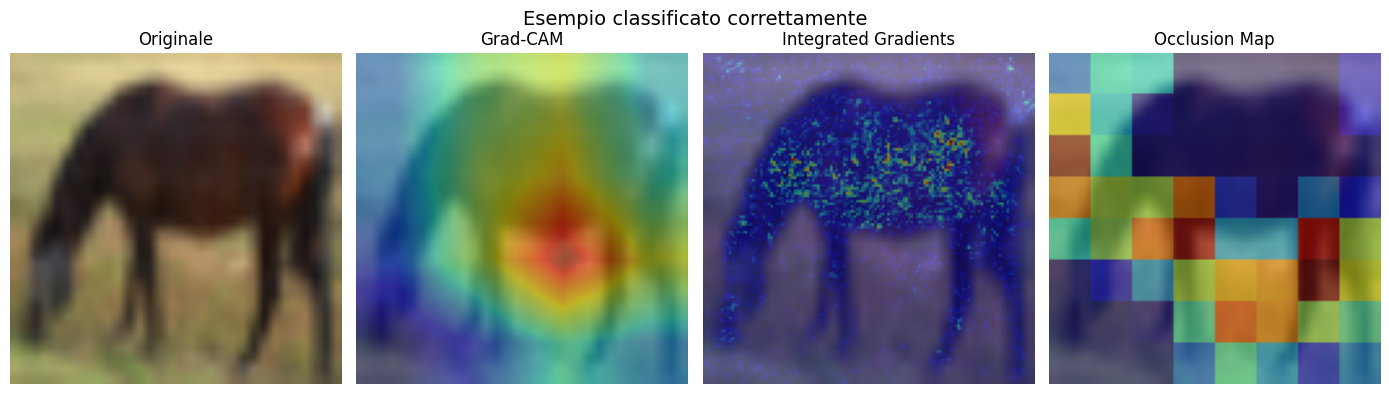

Esempio classificato in modo errato
  Classe reale:    cat
  Classe predetta: truck
  Confidenza sulla classe predetta: 0.291


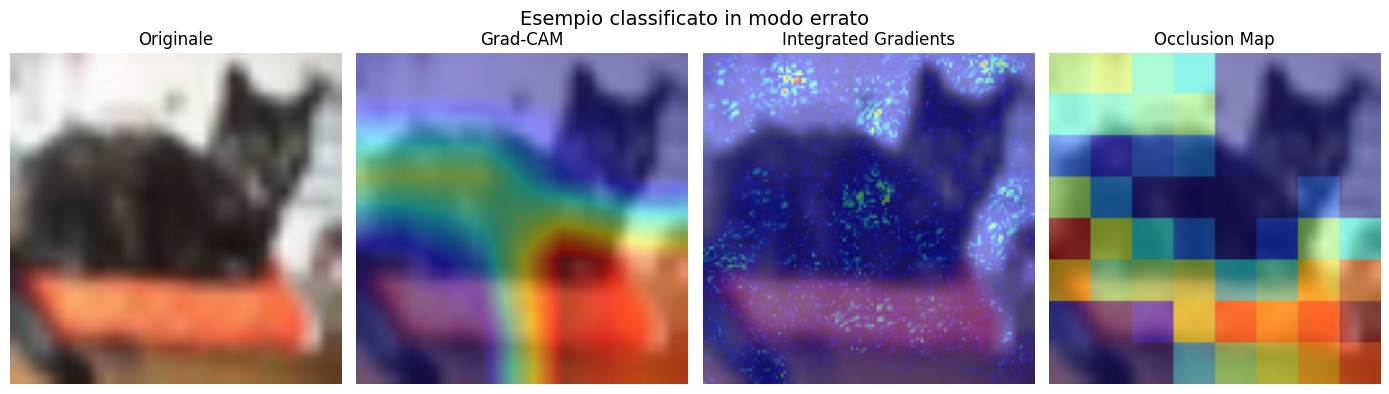

In [9]:
def explain_example(example, title):
    if example is None:
        print(title, "non disponibile.")
        return

    image, true_label, predicted_label = example
    target_class = predicted_label

    model.eval()
    with torch.no_grad():
        probabilities = F.softmax(model(image.to(device)), dim=1)
        confidence = probabilities[0, predicted_label].item()

    print(title)
    print("  Classe reale:   ", class_names[true_label])
    print("  Classe predetta:", class_names[predicted_label])
    print(f"  Confidenza sulla classe predetta: {confidence:.3f}")

    original = tensor_to_image(image)
    cam = grad_cam(model, image, target_class)
    ig = integrated_gradients(model, image, target_class, steps=25)
    occ = occlusion_map(model, image, target_class, patch_size=32, stride=16)

    maps = [cam, ig, occ]
    names = ["Grad-CAM", "Integrated Gradients", "Occlusion Map"]

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(original)
    plt.title("Originale")
    plt.axis("off")

    for i, (heatmap, name) in enumerate(zip(maps, names), start=2):
        plt.subplot(1, 4, i)
        plt.imshow(overlay_heatmap(original, heatmap))
        plt.title(name)
        plt.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


explain_example(correct_example, "Esempio classificato correttamente")
explain_example(wrong_example, "Esempio classificato in modo errato")


## 10. Come interpretare le mappe

Le mappe non danno una prova matematica assoluta, ma aiutano a capire il comportamento del modello.

Una classificazione e piu affidabile quando le mappe evidenziano parti coerenti con l'oggetto principale. Per esempio, nel caso di un cane, una spiegazione utile dovrebbe concentrarsi sul corpo, sul muso o su elementi visivi collegati all'animale.

Una classificazione e meno affidabile quando le mappe evidenziano soprattutto sfondo, bordi, rumore o elementi non collegati alla classe predetta. In questo caso il modello potrebbe aver imparato correlazioni deboli o non desiderate.

Nel contesto bancario, questo tipo di controllo serve a individuare decisioni potenzialmente rischiose. Per esempio, in un modello di valutazione del credito, una spiegazione dovrebbe basarsi su variabili pertinenti e consentite, non su informazioni indirette, instabili o non giustificabili.


## 11. Report finale

### Descrizione del dataset

Il dataset usato e **CIFAR-10**, composto da immagini a colori appartenenti a 10 classi. E un dataset pubblico e molto usato per esperimenti di classificazione. In questo progetto e stato usato un sottoinsieme ridotto per mantenere l'esecuzione semplice e veloce in Google Colab.

### Descrizione del modello

Il modello scelto e **DenseNet121**, una rete neurale convoluzionale pre-addestrata su ImageNet. La parte convoluzionale e stata mantenuta come estrattore di caratteristiche, mentre l'ultimo livello e stato sostituito e addestrato sulle 10 classi di CIFAR-10.

### Tecniche XAI usate

- **Grad-CAM:** mostra le aree dell'immagine piu importanti per la decisione finale della rete.
- **Integrated Gradients:** attribuisce un contributo ai pixel confrontando l'immagine reale con una baseline neutra.
- **Occlusion Map:** oscura parti dell'immagine e osserva quanto diminuisce la confidenza del modello.

### Analisi delle decisioni corrette ed errate

Nel caso corretto, ci aspettiamo che le mappe evidenzino l'oggetto principale. Questo aumenta la fiducia nella decisione, perche il modello sembra usare informazioni coerenti con la classe predetta.

Nel caso errato, le mappe possono evidenziare zone poco informative o dettagli secondari. Questo aiuta a capire dove il modello si e confuso e suggerisce possibili miglioramenti, come piu dati, migliore bilanciamento del dataset, data augmentation o un addestramento piu lungo.

### Collegamento alla compliance bancaria

In ambito bancario, la trasparenza dei modelli e fondamentale. Le tecniche XAI aiutano a:

- spiegare le decisioni del modello agli stakeholder;
- individuare errori o comportamenti anomali;
- ridurre il rischio di decisioni non giustificabili;
- supportare audit, governance e conformita normativa.

Anche se questo notebook usa immagini, il principio e lo stesso per modelli bancari su dati tabellari. In quel caso si potrebbero usare tecniche come SHAP o LIME per spiegare quali variabili hanno influenzato una decisione su credito, rischio, frode o compliance.


## 12. Sistema spiegabile opzionale

Un sistema completamente spiegabile potrebbe usare un modello piu semplice, per esempio:

- una regressione logistica;
- un albero decisionale;
- un sistema a regole controllato da esperti di dominio.

Nel caso bancario, un modello interpretabile potrebbe classificare una pratica usando variabili come reddito, rapporto rata/reddito, storico dei pagamenti, esposizione debitoria e anzianita del rapporto con la banca.

Il vantaggio e che ogni decisione puo essere spiegata in modo diretto. Lo svantaggio e che un modello molto semplice puo avere prestazioni inferiori rispetto a una rete neurale o a un modello complesso.

Una soluzione realistica e usare entrambe le cose:

- modello complesso per ottenere buone prestazioni;
- tecniche XAI e controlli di audit per spiegare e monitorare le decisioni.


## Conclusione

Questo progetto mostra come una rete neurale possa essere interpretata con mappe di salienza.  
Le spiegazioni rendono il modello piu trasparente e aiutano a distinguere decisioni plausibili da decisioni sospette.

Per Banca Virtuosa, un approccio di questo tipo permette di migliorare fiducia, controllo degli errori, governance e conformita normativa.
